In [1]:
import pandas as pd
import numpy as np
import random
import os
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 데이터를 확인하기 위해 head() 함수를 사용합니다.
train.head(1)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.1,1,98,40,80,1.3,211,75,120,15.9,1,1.53,1


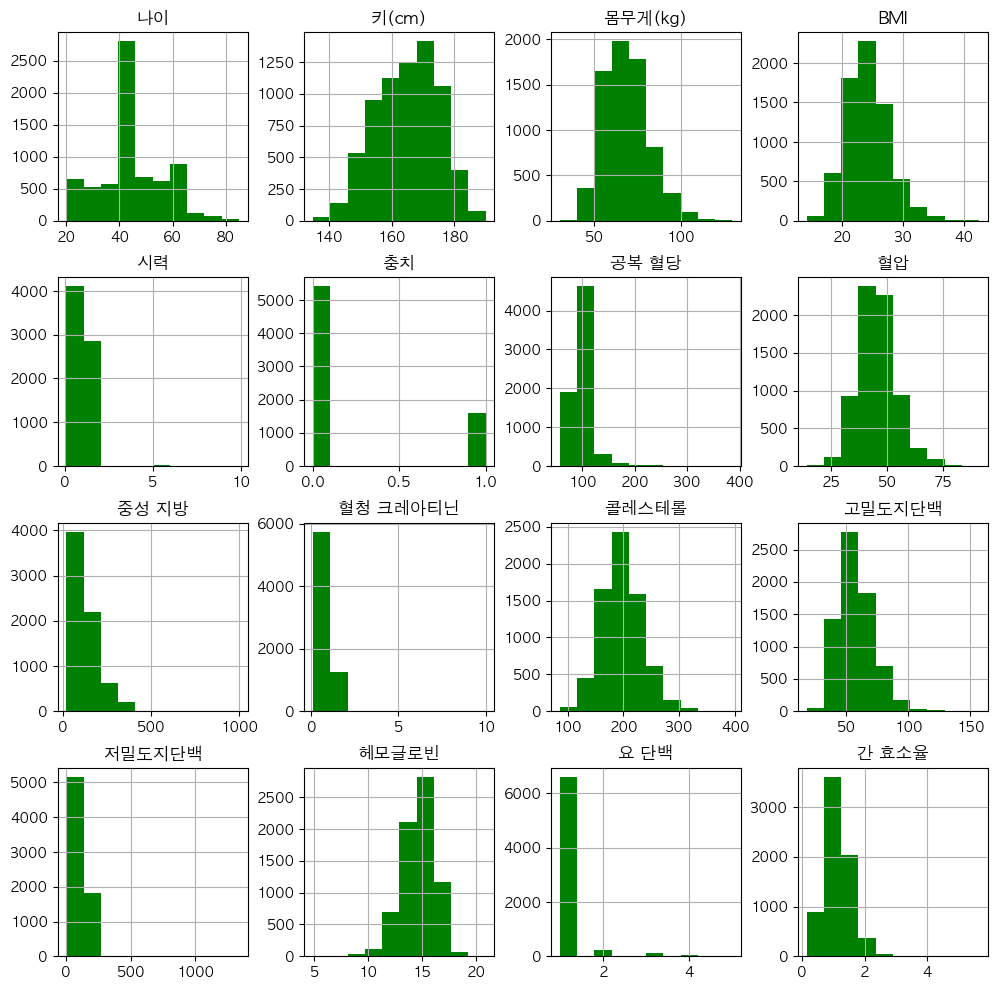

In [71]:
except_target = train.drop('label', axis = 1)
except_target.hist(figsize = (12,12), color='green')
plt.show()

In [69]:
cols = [
    '나이', '키(cm)', '몸무게(kg)', 'BMI', '시력', '충치', '공복 혈당', '혈압',
    '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백',
    '헤모글로빈', '요 단백', '간 효소율'
]

summary_df = train[cols].agg(['min', 'max']).T
summary_df = summary_df.reset_index()
summary_df.columns = ['컬럼명', '최소값', '최대값']

print(summary_df.to_string(index=False))

     컬럼명    최소값     최대값
      나이  20.00   85.00
   키(cm) 135.00  190.00
 몸무게(kg)  30.00  130.00
     BMI  14.27   42.45
      시력   0.10    9.90
      충치   0.00    1.00
   공복 혈당  57.00  386.00
      혈압  14.00   91.00
   중성 지방  21.00  999.00
혈청 크레아티닌   0.10   10.00
   콜레스테롤  86.00  395.00
  고밀도지단백  18.00  157.00
  저밀도지단백   1.00 1340.00
   헤모글로빈   4.90   20.90
    요 단백   1.00    5.00
   간 효소율   0.14    5.67


In [5]:
# 나이
20~85세

In [6]:
# 큰 값 10개 (내림차순)
train['나이'].nlargest(10)

2664    85
3190    85
4680    85
148     80
267     80
419     80
593     80
857     80
900     80
902     80
Name: 나이, dtype: int64

In [7]:
# 작은 값 10개 (오름차순)
train['나이'].nsmallest(10)

26     20
33     20
42     20
53     20
68     20
94     20
270    20
298    20
360    20
427    20
Name: 나이, dtype: int64

In [8]:
# 키(cm)
성인 기준으로 147cm 이하일 경우 왜소증으로 판단

In [58]:
# 큰 값 10개 (내림차순)
train['키(cm)'].nlargest(10)

2979    190
5738    190
133     185
142     185
151     185
155     185
403     185
421     185
517     185
533     185
Name: 키(cm), dtype: int64

In [10]:
# 작은 값 10개 (오름차순)
train['키(cm)'].nsmallest(10)

1125    135
75      140
80      140
244     140
426     140
529     140
851     140
907     140
1286    140
1574    140
Name: 키(cm), dtype: int64

In [11]:
# 몸무게(kg)
147cm 기준으로 39kg 이하는 저체중임으로

In [12]:
# 큰 값 10개 (내림차순)
train['몸무게(kg)'].nlargest(10)

4563    130
1836    125
5643    125
5921    125
731     120
3153    120
3539    120
3822    120
2159    115
2554    115
Name: 몸무게(kg), dtype: int64

In [13]:
# 작은 값 10개 (오름차순)
train['몸무게(kg)'].nsmallest(10)

6926    30
80      35
1124    35
1125    35
1982    35
2002    35
2100    35
3649    35
4120    35
4620    35
Name: 몸무게(kg), dtype: int64

In [14]:
# BMI
16이하의 BMI는 곧 가셔야되는  BMI…
16 이하는 없애야됨…

In [15]:
# 큰 값 10개 (내림차순)
train['BMI'].nlargest(10)

4563    42.45
6933    41.62
1836    40.82
5643    40.82
5921    40.82
3153    39.18
3822    39.18
2822    38.06
4715    38.06
5269    37.78
Name: BMI, dtype: float64

In [16]:
# 작은 값 10개 (오름차순)
train['BMI'].nsmallest(10)

6926    14.27
2002    15.56
3649    15.56
4120    15.56
2974    15.57
3703    15.57
4397    15.57
6670    15.57
1260    15.62
1486    15.62
Name: BMI, dtype: float64

In [17]:
# 시력
2.0~3.0 이상이 되기는 힘들다.. 
3.0 이상부터는 이상치라고 봐야됨

In [18]:
# 큰 값 10개 (내림차순)
train['시력'].nlargest(10)

6003    9.90
3909    5.95
355     5.70
2911    5.70
3856    5.70
3886    5.70
5218    5.70
5675    5.70
596     5.55
1896    5.55
Name: 시력, dtype: float64

In [19]:
# 작은 값 10개 (오름차순)
train['시력'].nsmallest(10)

764     0.1
793     0.1
947     0.1
1031    0.1
1530    0.1
2048    0.1
2329    0.1
3636    0.1
3739    0.1
4176    0.1
Name: 시력, dtype: float64

In [20]:
hyeye= (train['시력'] > 3.0).sum()
print(hyeye)

30


In [ ]:
# 충치는 있다 없다의 기준으로 이상치는 없다고 봐야됨

In [72]:
# 작은 값 10개 (오름차순)
train['충치'].nsmallest(10)

1     0
2     0
3     0
4     0
5     0
7     0
8     0
9     0
10    0
11    0
Name: 충치, dtype: int64

In [21]:
# 공복 혈당
정상인은 췌장에 랑게르한스섬의 알파세포에서 혈당을 높이는 글루카곤을 분비 되기 때문에 괜찮지만
70이하의 혈당에서 증상과 동반된 경우이거나 당뇨병 환자의 경우에는 저혈당으로 치료 받아야될 수치입니다. 사실 정상인도 위험할수치라고 봐야됩니ㅏㄷ...

데이터에는 다른 정보를 제외한 수치만 나와있기 때문에 60미만인 이상치(1개있음)만 줄이는 것이 좋아 보임

In [22]:
# 큰 값 10개 (내림차순)
train['공복 혈당'].nlargest(10)

3437    386
1523    375
1486    342
3492    314
4673    313
6982    308
4274    302
5721    290
837     288
477     285
Name: 공복 혈당, dtype: int64

In [23]:
# 작은 값 10개 (오름차순)
train['공복 혈당'].nsmallest(10)

1533    57
6637    60
614     61
6313    61
1588    64
602     65
1195    65
1720    65
3338    65
4526    65
Name: 공복 혈당, dtype: int64

In [24]:
# 혈압
혈압에는 수축기혈압 이완기 혈압이 있는데 데이터를 보면 이완기혈압의 데이터로 보여집니다.
    
수축기 혈압은 심장이 수축하여 동맥혈관으로 혈액을 보낼 때의 압력

이완기혈압은 심장이 이완될때 즉 혈액이 심장안으로 들어갈때 가장 낮은 혈압을 의미합니다.

30 이하면 천국가야되는 정도인데..
30이하 이완기혈압이 280개임…
20 이하만 일단 줄임 (11개)

In [25]:
# 큰 값 10개 (내림차순)
train['혈압'].nlargest(10)

593     91
2213    89
2247    88
5804    85
1113    82
2608    82
4730    82
5640    82
6634    82
6976    81
Name: 혈압, dtype: int64

In [26]:
# 작은 값 10개 (오름차순)
train['혈압'].nsmallest(10)

4612    14
289     17
6836    17
2416    19
791     20
1259    20
1415    20
2462    20
2794    20
4465    20
Name: 혈압, dtype: int64

In [73]:
hypoBP = (train['혈압'] <= 30).sum()
print(hypoBP)

280


In [28]:
# 중성 지방 (TG)
500 mg/dL 이상이면 췌장염으로 가는 고속도로
999인 사람 1개있음 이미 죽었음
30이하면… 병원에 입원해있어야됨..
30 미만인 사람 33개있음…. -> 25이하 4명 이라 없앰

In [29]:
# 큰 값 10개 (내림차순)
train['중성 지방'].nlargest(10)

5839    999
5796    399
1273    398
1708    397
5390    397
5446    397
5947    397
6388    397
6719    397
5281    396
Name: 중성 지방, dtype: int64

In [30]:
# 작은 값 10개 (오름차순)
train['중성 지방'].nsmallest(10)

1085    21
1252    23
6324    23
6523    23
2358    25
5658    25
6573    25
6726    25
2594    26
2709    27
Name: 중성 지방, dtype: int64

In [31]:
hyTG = (train['중성 지방'] > 500).sum()
print(hyTG)

1


In [32]:
lowTG = (train['중성 지방'] < 25).sum()
print(lowTG)

4


In [33]:
# 혈청 크레아티닌
0.5이하…
0.3이하인 사람 3명있음

5.0 이상 3명 이사람들은 곧 죽어야됨..

In [75]:
# 큰 값 10개 (내림차순)
train['혈청 크레아티닌'].nlargest(20)

3965    10.0
2335     7.4
3498     5.9
4492     2.6
5914     2.5
577      2.0
593      2.0
2261     2.0
5350     1.9
5193     1.7
6904     1.7
311      1.6
610      1.6
617      1.6
818      1.6
1977     1.6
3188     1.6
5848     1.6
89       1.5
659      1.5
Name: 혈청 크레아티닌, dtype: float64

In [35]:
# 작은 값 10개 (오름차순)
train['혈청 크레아티닌'].nsmallest(10)

1035    0.1
4575    0.1
2164    0.3
227     0.4
535     0.4
935     0.4
1411    0.4
1940    0.4
2248    0.4
2315    0.4
Name: 혈청 크레아티닌, dtype: float64

In [36]:
# 콜레스테롤
300이상시 의사와 면담이 필요합니다.

In [37]:
# 큰 값 10개 (내림차순)
train['콜레스테롤'].nlargest(10)

3709    395
2136    386
5370    380
5138    375
3136    369
2713    366
821     363
21      351
2990    338
3375    333
Name: 콜레스테롤, dtype: int64

In [38]:
# 작은 값 10개 (오름차순)
train['콜레스테롤'].nsmallest(10)

2693     86
4904     95
1527     97
2664     98
4243     98
5803     98
6128     98
3184    100
2061    101
3770    101
Name: 콜레스테롤, dtype: int64

In [39]:
# 고밀도지단백
혈중 HDL 콜레스테롤의 정상 수치는 남성이 40~60mg/dL, 여성은 50~60mg/dL

HDL 콜레스테롤 혈중 수치가 80mg/dL 이상
 HDL 콜레스테롤 수치가 정상 범위인 노인보다 치매 진단율이 27% 높은 것

In [40]:
# 큰 값 10개 (내림차순)
train['고밀도지단백'].nlargest(10)

6049    157
5433    133
5826    132
2388    131
1907    127
12      125
2025    125
3858    125
1537    123
3648    123
Name: 고밀도지단백, dtype: int64

In [41]:
# 작은 값 10개 (오름차순)
train['고밀도지단백'].nsmallest(10)

1339    18
4289    22
3698    24
5863    24
6301    24
6430    24
1864    25
2548    25
196     26
3184    26
Name: 고밀도지단백, dtype: int64

In [42]:
# 저밀도지단백
300이상  6명
30이하 20명


In [43]:
# 큰 값 10개 (내림차순)
train['저밀도지단백'].nlargest(10)

4923    1340
6700    1120
2107    1070
6898     910
5350     590
2136     307
5138     295
5370     293
2713     292
3709     282
Name: 저밀도지단백, dtype: int64

In [44]:
# 작은 값 10개 (오름차순)
train['저밀도지단백'].nsmallest(10)

583      1
389     12
2061    12
6128    15
2772    16
5323    16
6407    16
2900    18
4243    19
1368    22
Name: 저밀도지단백, dtype: int64

In [74]:
hyLDL= (train['저밀도지단백'] > 300).sum()
print(hyLDL)

6


In [46]:
# 헤모글로빈
7.0 이하는 병원가는중
18 이상은(44명) 탈수 의심..
18.5 이상 (12명) ->으로 기준 낮춤


In [47]:
# 큰 값 10개 (내림차순)
train['헤모글로빈'].nlargest(10)

4997    20.9
1509    20.0
311     19.3
1596    19.1
4696    19.1
192     18.8
2371    18.8
6055    18.8
6127    18.8
1255    18.7
Name: 헤모글로빈, dtype: float64

In [48]:
# 작은 값 10개 (오름차순)
train['헤모글로빈'].nsmallest(10)

4831    4.9
3895    6.2
6279    7.2
3617    7.6
1713    7.7
594     7.9
4194    7.9
4188    8.0
5712    8.0
1551    8.3
Name: 헤모글로빈, dtype: float64

In [49]:
hyHb= (train['헤모글로빈'] >= 18).sum()
print(hyHb)

44


In [50]:
# 요 단백
3.5 이상이면 신장 박살남 -> 44명
4.0 (10명)

In [51]:
# 큰 값 10개 (내림차순)
train['요 단백'].nlargest(10)

617     5
2335    5
3667    5
4255    5
4492    5
4730    5
5413    5
5848    5
6487    5
6925    5
Name: 요 단백, dtype: int64

In [52]:
# 작은 값 10개 (오름차순)
train['요 단백'].nsmallest(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: 요 단백, dtype: int64

In [53]:
hyCr= (train['요 단백'] > 4).sum()
print(hyCr)

10


In [54]:
# 간 효소율
‘간효소율’ -> 총빌리루빈이라고 봄


In [55]:
# 큰 값 10개 (내림차순)
train['간 효소율'].nlargest(10)

313     5.67
2967    5.47
5458    5.33
3665    5.17
1121    4.17
1006    4.00
2149    4.00
3394    4.00
5665    4.00
6090    4.00
Name: 간 효소율, dtype: float64

In [56]:
# 작은 값 10개 (오름차순)
train['간 효소율'].nsmallest(10)

4200    0.14
2731    0.29
3940    0.31
1229    0.32
2286    0.34
6422    0.34
1359    0.36
1386    0.36
3101    0.36
363     0.37
Name: 간 효소율, dtype: float64

In [57]:
hyliver= (train['간 효소율'] > 3 ).sum()
print(hyliver)

25
